In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_csv('Data/Social_Network_Ads.csv', index_col=0)

In [3]:
data.head(1)

,Gender,Age,EstimatedSalary,Purchased
User ID,,,,
15624510,Male,19,19000,0


In [4]:
x = data.iloc[:,1:-1].values
y = data.iloc[:,-1].values

In [5]:
"""
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
x = ct.fit_transform(x)"""

"\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.preprocessing import OneHotEncoder\nct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')\nx = ct.fit_transform(x)"

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=67)

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(x_test)

In [ ]:
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)),1))

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[49  5]
 [16 30]]
              precision    recall  f1-score   support

           0       0.75      0.91      0.82        54
           1       0.86      0.65      0.74        46

    accuracy                           0.79       100
   macro avg       0.81      0.78      0.78       100
weighted avg       0.80      0.79      0.79       100



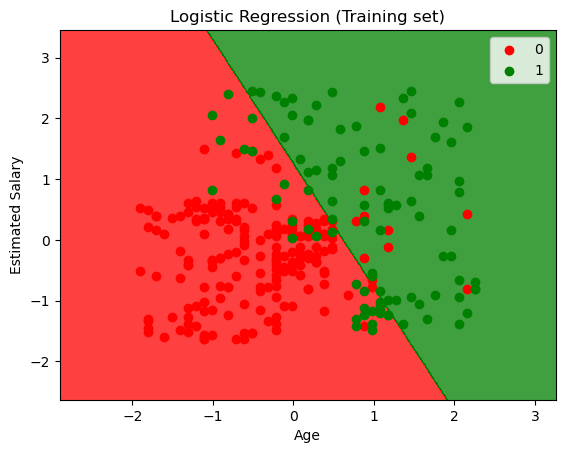

In [12]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = x_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:,0].min()-1, stop=X_set[:,0].max()+1, step=0.01),
    np.arange(start=X_set[:,1].min()-1, stop=X_set[:,1].max()+1, step=0.01)
)

plt.contourf(
    X1,
    X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red','green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color=ListedColormap(('red','green'))(i),
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

C:\Users\hicha\AppData\Local\Temp\ipykernel_12140\3292255151.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


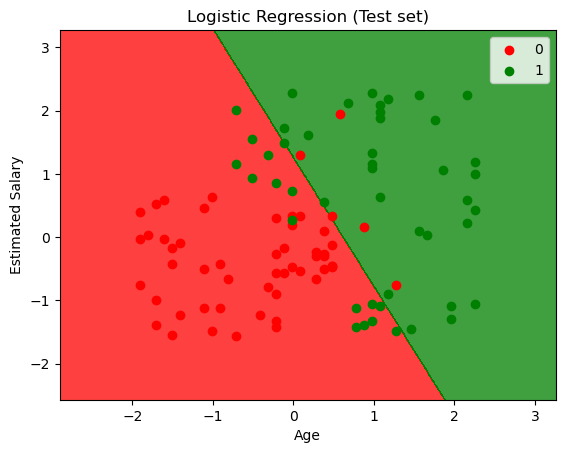

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_set, y_set = x_test, y_test   # make sure names match

X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min() - 1, X_set[:,0].max() + 1, 0.01),
    np.arange(X_set[:,1].min() - 1, X_set[:,1].max() + 1, 0.01)
)

plt.contourf(
    X1, 
    X2, 
    model.predict(np.c_[X1.ravel(), X2.ravel()]).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red','green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red','green'))(i),
        label=j
    )

plt.title("Logistic Regression (Test set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()